<a href="https://colab.research.google.com/github/garciaguadalupevanessa-bit/Tablas_de_ventas/blob/main/ventas_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ Solución Ejercicio — Tabla de Ventas
**Análisis completo con Python:** carga de CSV, columna total, estadísticas, filtros, mes en texto, tabla dinámica y gráfico de barras.

---

## 📦 Celda 1 — Importaciones

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from io import StringIO

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 📂 Celda 2 — Cargar el CSV
> **Opción A:** Sube tu archivo `ventas.csv` manualmente con `files.upload()`  
> **Opción B:** Usa los datos embebidos directamente (activa por defecto)

In [ ]:
# ── Opción A: subir archivo desde tu ordenador ──
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0], parse_dates=['fecha'])

# ── Opción B: datos embebidos (ventas.csv original) ──
csv_raw = """fecha,producto,precio,unidades
2024-01-01,Camiseta,20,5
2024-01-02,Pantalón,30,2
2024-01-03,Camiseta,20,3
2024-01-04,Zapatillas,50,1
2024-01-05,Pantalón,30,4
2024-01-06,Sudadera,35,2
2024-01-07,Zapatillas,50,2
2024-01-08,Camiseta,20,6
2024-01-09,Pantalón,30,1
2024-01-10,Sudadera,35,3"""

df = pd.read_csv(StringIO(csv_raw), parse_dates=['fecha'])

print('✅ Dataset cargado correctamente')
print(f'   Filas: {len(df)} | Columnas: {list(df.columns)}')
df

✅ Dataset cargado correctamente
   Filas: 10 | Columnas: ['fecha', 'producto', 'precio', 'unidades']


,fecha,producto,precio,unidades
0,2024-01-01,Camiseta,20,5
1,2024-01-02,Pantalón,30,2
2,2024-01-03,Camiseta,20,3
3,2024-01-04,Zapatillas,50,1
4,2024-01-05,Pantalón,30,4
5,2024-01-06,Sudadera,35,2
6,2024-01-07,Zapatillas,50,2
7,2024-01-08,Camiseta,20,6
8,2024-01-09,Pantalón,30,1
9,2024-01-10,Sudadera,35,3


## ➕ Celda 3 — Columna TOTAL
Se calcula como: **`total = precio × unidades`**

In [ ]:
df['total'] = df['precio'] * df['unidades']

print('✅ Columna total creada (precio × unidades)')
df[['fecha', 'producto', 'precio', 'unidades', 'total']]

✅ Columna total creada (precio × unidades)


,fecha,producto,precio,unidades,total
0,2024-01-01,Camiseta,20,5,100
1,2024-01-02,Pantalón,30,2,60
2,2024-01-03,Camiseta,20,3,60
3,2024-01-04,Zapatillas,50,1,50
4,2024-01-05,Pantalón,30,4,120
5,2024-01-06,Sudadera,35,2,70
6,2024-01-07,Zapatillas,50,2,100
7,2024-01-08,Camiseta,20,6,120
8,2024-01-09,Pantalón,30,1,30
9,2024-01-10,Sudadera,35,3,105


## 📊 Celda 4 — Estadísticas: PROMEDIO, SUMA, MÁX

In [ ]:
promedio = df['total'].mean()
suma     = df['total'].sum()
maximo   = df['total'].max()

stats = pd.DataFrame({
    'Estadística': ['PROMEDIO', 'SUMA', 'MÁX'],
    'Valor (€)':  [promedio, suma, maximo]
})
stats['Valor (€)'] = stats['Valor (€)'].map(lambda x: f'{x:.2f} €')

print('📊 Estadísticas de la columna TOTAL:')
stats

📊 Estadísticas de la columna TOTAL:


,Estadística,Valor (€)
0,PROMEDIO,81.50 €
1,SUMA,815.00 €
2,MÁX,120.00 €


## 🔍 Celda 5 — Filtro: productos con ingresos > 100 €

In [ ]:
df_filtrado = df[df['total'] > 100].copy().reset_index(drop=True)

print(f'✅ Registros con total > 100 €: {len(df_filtrado)} de {len(df)}')
df_filtrado

✅ Registros con total > 100 €: 3 de 10


,fecha,producto,precio,unidades,total
0,2024-01-05,Pantalón,30,4,120
1,2024-01-08,Camiseta,20,6,120
2,2024-01-10,Sudadera,35,3,105


## 📅 Celda 6 — Mes en texto desde la columna fecha

In [ ]:
MESES_ES = {
    1:'enero', 2:'febrero', 3:'marzo',    4:'abril',
    5:'mayo',  6:'junio',   7:'julio',    8:'agosto',
    9:'septiembre', 10:'octubre', 11:'noviembre', 12:'diciembre'
}

df['mes'] = df['fecha'].dt.month.map(MESES_ES)

print('✅ Columna mes extraída en texto:')
df[['fecha', 'mes', 'producto', 'total']]

✅ Columna mes extraída en texto:


,fecha,mes,producto,total
0,2024-01-01,enero,Camiseta,100
1,2024-01-02,enero,Pantalón,60
2,2024-01-03,enero,Camiseta,60
3,2024-01-04,enero,Zapatillas,50
4,2024-01-05,enero,Pantalón,120
5,2024-01-06,enero,Sudadera,70
6,2024-01-07,enero,Zapatillas,100
7,2024-01-08,enero,Camiseta,120
8,2024-01-09,enero,Pantalón,30
9,2024-01-10,enero,Sudadera,105


## 💾 Celda 7 — Exportar dataset procesado como CSV

In [ ]:
df.to_csv('ventas_procesado.csv', index=False, encoding='utf-8-sig')
print('✅ Archivo guardado: ventas_procesado.csv')

# Para descargarlo directamente en Colab descomenta:
# from google.colab import files
# files.download('ventas_procesado.csv')

df

✅ Archivo guardado: ventas_procesado.csv


,fecha,producto,precio,unidades,total,mes
0,2024-01-01,Camiseta,20,5,100,enero
1,2024-01-02,Pantalón,30,2,60,enero
2,2024-01-03,Camiseta,20,3,60,enero
3,2024-01-04,Zapatillas,50,1,50,enero
4,2024-01-05,Pantalón,30,4,120,enero
5,2024-01-06,Sudadera,35,2,70,enero
6,2024-01-07,Zapatillas,50,2,100,enero
7,2024-01-08,Camiseta,20,6,120,enero
8,2024-01-09,Pantalón,30,1,30,enero
9,2024-01-10,Sudadera,35,3,105,enero


## 🔄 Celda 8 — Tabla dinámica: ingresos por producto y mes

In [ ]:
pivot = df.pivot_table(
    values='total',
    index='producto',
    columns='mes',
    aggfunc='sum',
    fill_value=0
)

# Ordenar columnas por mes calendario
orden_meses = [m for m in MESES_ES.values() if m in pivot.columns]
pivot = pivot[orden_meses]
pivot['TOTAL'] = pivot.sum(axis=1)

# Formato euro
pivot_display = pivot.applymap(lambda x: f'{x:.2f} €')

print('📊 Tabla dinámica — Ingresos totales por producto y mes:')
pivot_display

📊 Tabla dinámica — Ingresos totales por producto y mes:


/tmp/ipykernel_827/1875998078.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_display = pivot.applymap(lambda x: f'{x:.2f} €')


mes,enero,TOTAL
producto,,
Camiseta,280.00 €,280.00 €
Pantalón,210.00 €,210.00 €
Sudadera,175.00 €,175.00 €
Zapatillas,150.00 €,150.00 €


## 📈 Celda 9 — Gráfico de barras

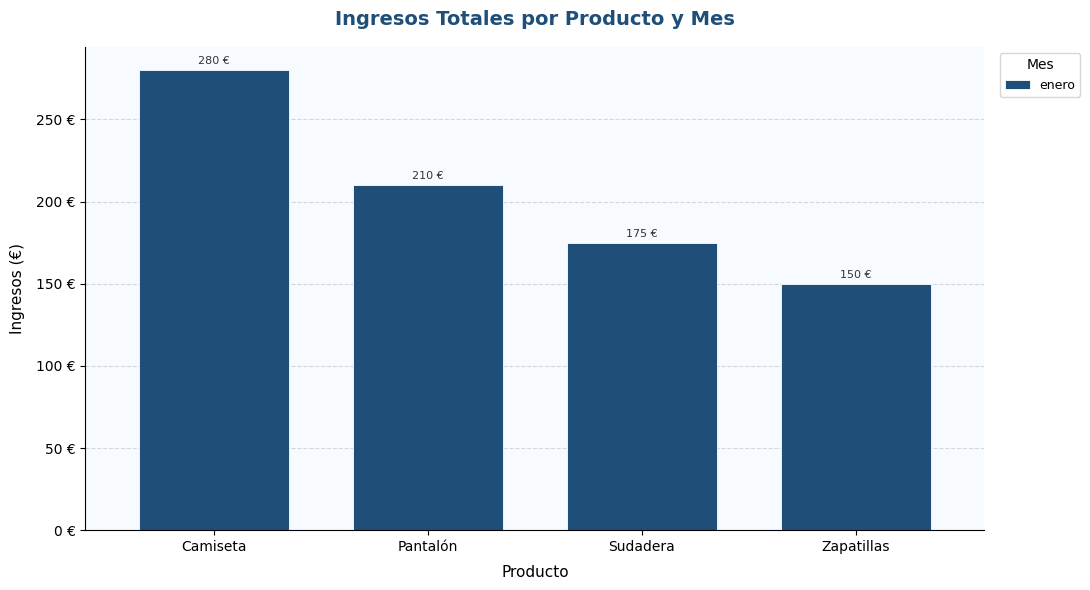

✅ Gráfico guardado como grafico_ventas.png


In [ ]:
pivot_chart = pivot.drop(columns='TOTAL')

fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#1F4E79', '#2E75B6', '#5BA3D0', '#A8D1F0']
pivot_chart.plot(
    kind='bar',
    ax=ax,
    color=colors[:len(pivot_chart.columns)],
    edgecolor='white',
    linewidth=0.6,
    width=0.7
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f €', fontsize=8, padding=3, color='#333333')

ax.set_title('Ingresos Totales por Producto y Mes', fontsize=14,
             fontweight='bold', pad=16, color='#1F4E79')
ax.set_xlabel('Producto', fontsize=11, labelpad=8)
ax.set_ylabel('Ingresos (€)', fontsize=11, labelpad=8)
ax.set_xticklabels(pivot_chart.index, rotation=0, fontsize=10)
ax.legend(title='Mes', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.set_facecolor('#F7FBFF')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('grafico_ventas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado como grafico_ventas.png')

## ✅ Celda 10 — Resumen final

In [ ]:
print('=' * 50)
print('  RESUMEN FINAL')
print('=' * 50)
print(f'  Total de registros         : {len(df)}')
print(f'  Productos únicos           : {df["producto"].nunique()}')
print(f'  Período                    : {df["fecha"].min().date()} → {df["fecha"].max().date()}')
print(f'  PROMEDIO ingresos/venta    : {promedio:.2f} €')
print(f'  SUMA total de ingresos     : {suma:.2f} €')
print(f'  MÁX ingreso en una venta   : {maximo:.2f} €')
print(f'  Ventas con total > 100 €   : {len(df_filtrado)}')
print('=' * 50)

  RESUMEN FINAL
  Total de registros         : 10
  Productos únicos           : 4
  Período                    : 2024-01-01 → 2024-01-10
  PROMEDIO ingresos/venta    : 81.50 €
  SUMA total de ingresos     : 815.00 €
  MÁX ingreso en una venta   : 120.00 €
  Ventas con total > 100 €   : 3
